In [224]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [225]:

df = pd.read_csv("https://raw.githubusercontent.com/mehreengillani/Data602/refs/heads/main/Airbnb_site_hotel%20new.csv")
df.head(5)

/var/folders/6w/rkqvbjtx04s93768hcryddtc0000gn/T/ipykernel_44634/2535189215.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("https://raw.githubusercontent.com/mehreengillani/Data602/refs/heads/main/Airbnb_site_hotel%20new.csv")


,id,name,host_id,host_name,city,price,reply time,guest favourite,host since,host Certification,...,total reviewers number,accommodates,bathrooms,bedrooms,beds,listing number,host response rate,host acceptance rate,sales,area
0,1,Beautiful Victorian Home,1368256,Robert,Toronto,250,0.0,0,4563,1.0,...,47,6,"1,5",2,3,1,"0,9","0,42",102,North America
1,2,"World Class @ CN Tower, convention centre, The...",113345,Adela,Toronto,152,0.0,0,5120,1.0,...,42,4,1,1,2,5,"0,9","0,42",166,North America
2,3,Furnished room in lovely Annex house June -Oct31,1466410,Susan,Toronto,120,0.0,0,4534,1.0,...,0,1,1,1,2,2,1,"0,65",181,North America
3,4,Executive Studio Unit- Ideal for One Person,118124,Brent,Toronto,75,1.0,1,5111,1.0,...,29,1,1,0,1,1,1,1,365,North America
4,5,"Bright Beaches Apt, close to everything",175687,John,Toronto,90,0.0,0,5033,1.0,...,7,2,1,1,1,4,1,"0,8",328,North America


In [226]:
#summary
df.describe()

,id,host_id,reply time,guest favourite,host since,host Certification,room_type,host total listings count,total reviewers number,accommodates,bedrooms,beds,listing number,sales
count,86186.000000,8.618600e+04,66867.000000,86186.000000,86186.000000,82903.0,86186.000000,86186.000000,86186.000000,86186.000000,86186.000000,86186.000000,86186.000000,86186.000000
mean,43093.500000,1.959076e+08,0.769857,0.273304,2380.740236,1.0,2.663959,23.492737,36.414174,3.412747,1.247407,1.914441,45.196772,183.385086
std,24879.899487,1.849803e+08,0.420928,0.445658,1269.305372,0.0,0.524877,73.067586,75.989911,2.393287,1.093598,1.732507,258.312637,119.302210
min,1.000000,1.581000e+03,0.000000,0.000000,0.000000,1.0,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,21547.250000,2.890381e+07,1.000000,0.000000,1422.000000,1.0,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,80.000000
50%,43093.500000,1.308280e+08,1.000000,0.000000,2540.000000,1.0,3.000000,3.000000,9.000000,2.000000,1.000000,1.000000,3.000000,193.000000
75%,64639.750000,3.492982e+08,1.000000,1.000000,3337.000000,1.0,3.000000,12.000000,37.000000,4.000000,2.000000,2.000000,15.000000,287.000000
max,86186.000000,5.752345e+08,1.000000,1.000000,5745.000000,1.0,4.000000,837.000000,2575.000000,16.000000,21.000000,60.000000,4818.000000,365.000000


In [227]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86186 entries, 0 to 86185
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         86186 non-null  int64  
 1   name                       86186 non-null  object 
 2   host_id                    86186 non-null  int64  
 3   host_name                  86186 non-null  object 
 4   city                       86186 non-null  object 
 5   price                      80762 non-null  object 
 6   reply time                 66867 non-null  float64
 7   guest favourite            86186 non-null  int64  
 8   host since                 86186 non-null  int64  
 9   host Certification         82903 non-null  float64
 10  room_type                  86186 non-null  int64  
 11  host total listings count  86186 non-null  int64  
 12  consumer                   35421 non-null  object 
 13  total reviewers number     86186 non-null  int

In [228]:
print("Initial dataset shape:", df.shape)


Initial dataset shape: (86186, 23)


DATA CLEANING

In [229]:
# Step 2: Initial Data Assessment
print("Missing values before cleaning:")
print(df.isnull().sum().sort_values(ascending=False))

print("\nDataset overview:")
print(f"Total rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")

Missing values before cleaning:
consumer                     50765
reply time                   19319
price                         5424
host Certification            3283
id                               0
accommodates                     0
sales                            0
host acceptance rate             0
host response rate               0
listing number                   0
beds                             0
bedrooms                         0
bathrooms                        0
host total listings count        0
total reviewers number           0
name                             0
room_type                        0
host since                       0
guest favourite                  0
city                             0
host_name                        0
host_id                          0
area                             0
dtype: int64

Dataset overview:
Total rows: 86186
Total columns: 23


In [230]:
# Step 3: Handle Missing Values

# Create a copy for cleaning
df_clean = df.copy()

# Check percentage of missing values
missing_pct = (df_clean.isnull().sum() / len(df_clean)) * 100
print("Missing value percentage:")
print(missing_pct.sort_values(ascending=False).round(2))

Missing value percentage:
consumer                     58.90
reply time                   22.42
price                         6.29
host Certification            3.81
id                            0.00
accommodates                  0.00
sales                         0.00
host acceptance rate          0.00
host response rate            0.00
listing number                0.00
beds                          0.00
bedrooms                      0.00
bathrooms                     0.00
host total listings count     0.00
total reviewers number        0.00
name                          0.00
room_type                     0.00
host since                    0.00
guest favourite               0.00
city                          0.00
host_name                     0.00
host_id                       0.00
area                          0.00
dtype: float64


Analyze Missing Value Patterns and Prioritize Columns

Based on percentages missing value, here's the initial analysis and prioritization:


consumer (58.90%) - Very high missing rate - fillna - unknown
reply time (22.42%) - High missing rate
Moderate Missing (5-20%) - Imputation Candidates

price (6.29%) - Critical feature, needs careful imputation
host Certification (3.81%) - Moderate missing
Low/No Missing (<5%) - Safe to Keep

All other columns (0% missing) - No action needed

In [231]:
# Handle 'consumer' column (58.90% missing)
# Strategy: Create "Unknown" category since over half is missing

df_clean['consumer'] = df_clean['consumer'].fillna('Unknown')

print("✓ 'consumer' column: Missing values filled with 'Unknown'")
print(f"  Value counts: {df_clean['consumer'].value_counts().to_dict()}")

✓ 'consumer' column: Missing values filled with 'Unknown'
  Value counts: {'Unknown': 50765, '0': 6952, '7': 4901, '6,5': 1097, '6': 1012, '6,67': 998, '6,75': 890, '6,8': 702, '6,83': 685, '6,86': 600, '6,88': 584, '6,71': 565, '6,82': 498, '6,78': 486, '6,81': 462, '6,79': 459, '6,6': 442, '6,89': 428, '6,85': 421, '6,77': 408, '6,73': 400, '6,33': 399, '6,76': 398, '6,63': 372, '6,9': 371, '6,84': 370, '6,7': 360, '6,69': 357, '6,92': 344, '6,64': 334, '6,74': 328, '6,91': 322, '6,87': 309, '6,68': 305, '6,72': 298, '6,93': 297, '6,57': 279, '6,65': 277, '5': 271, '6,56': 269, '6,94': 254, '6,4': 232, '6,62': 220, '6,61': 214, '6,59': 200, '6,25': 199, '6,58': 199, '6,66': 191, '6,53': 182, '6,95': 174, '6,43': 170, '6,55': 164, '6,2': 145, '6,52': 144, '6,54': 139, '6,38': 138, '6,44': 132, '6,48': 126, '6,96': 126, '5,5': 122, '6,47': 121, '6,45': 107, '6,46': 103, '6,97': 99, '6,42': 97, '6,29': 96, '6,41': 86, '6,51': 84, '5,67': 83, '3': 76, '6,36': 74, '6,39': 74, '6,49': 71, 

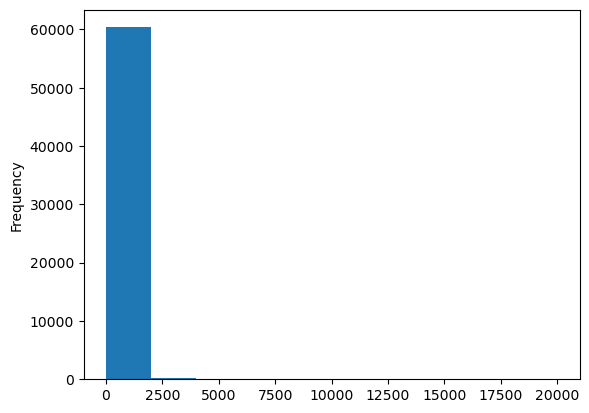

In [232]:
# Convert to numeric, set errors to NaN
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Then plot
df['price'].plot.hist()
plt.show()

In [233]:
print(df_clean.columns.tolist())

['id', 'name', 'host_id', 'host_name', 'city', 'price', 'reply time', 'guest favourite', 'host since', 'host Certification', 'room_type', 'host total listings count', 'consumer', 'total reviewers number', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'listing number', 'host response rate', 'host acceptance rate', 'sales', 'area']


In [234]:
# Step 3.2: Convert grouping columns to consistent data types
print("\n=== CONVERTING DATA TYPES ===")

# Convert price to numeric
df_clean['price'] = pd.to_numeric(df_clean['price'], errors='coerce')

# Convert bedrooms to numeric (in case it's string)
df_clean['bedrooms'] = pd.to_numeric(df_clean['bedrooms'], errors='coerce')

# Convert host response rate to numeric (remove % if present)
if df_clean['host response rate'].dtype == 'object':
    df_clean['host response rate'] = df_clean['host response rate'].astype(str).str.replace('%', '').str.strip()
    df_clean['host response rate'] = pd.to_numeric(df_clean['host response rate'], errors='coerce')

# Ensure area is string (categorical)
df_clean['area'] = df_clean['area'].astype(str)

print("After conversion:")
print(f"room_type: {df_clean['room_type'].dtype}")
print(f"bedrooms: {df_clean['bedrooms'].dtype}")
print(f"area: {df_clean['area'].dtype}")
print(f"host response rate: {df_clean['host response rate'].dtype}")
print(f"price: {df_clean['price'].dtype}")
print(f"reply time: {df_clean['reply time'].dtype}")


=== CONVERTING DATA TYPES ===
After conversion:
room_type: int64
bedrooms: int64
area: object
host response rate: float64
price: float64
reply time: float64


In [235]:
print("Before imputation - Missing reply time:", df_clean['reply time'].isnull().sum())

# First: Try imputing by host response rate groups
df_clean['reply time'] = df_clean.groupby('host response rate')['reply time'].transform(
    lambda x: x.fillna(x.median()) if x.notna().any() else x
)

print("After group imputation - Missing reply time:", df_clean['reply time'].isnull().sum())

# Second: If still missing, use overall median
if df_clean['reply time'].isnull().sum() > 0:
    overall_median = df_clean['reply time'].median()
    df_clean['reply time'] = df_clean['reply time'].fillna(overall_median)
    print(f"After overall median - Missing reply time: {df_clean['reply time'].isnull().sum()}")

Before imputation - Missing reply time: 19319
After group imputation - Missing reply time: 17094
After overall median - Missing reply time: 0


In [236]:
print(df_clean['reply time'].isnull().sum())

0


In [237]:
df_clean['price'] = df_clean['price'].fillna(
    df_clean.groupby(['room_type', 'bedrooms'])['price'].transform('median')
).fillna(df_clean['price'].median())

print(f"Missing prices: {df_clean['price'].isnull().sum()}")

Missing prices: 0



=== CREATING DISTRIBUTION PLOTS ===
Final data status:
df price - dtype: float64, missing: 25472
df_clean price - dtype: float64, missing: 0
df reply time - dtype: float64, missing: 19319
df_clean reply time - dtype: float64, missing: 0


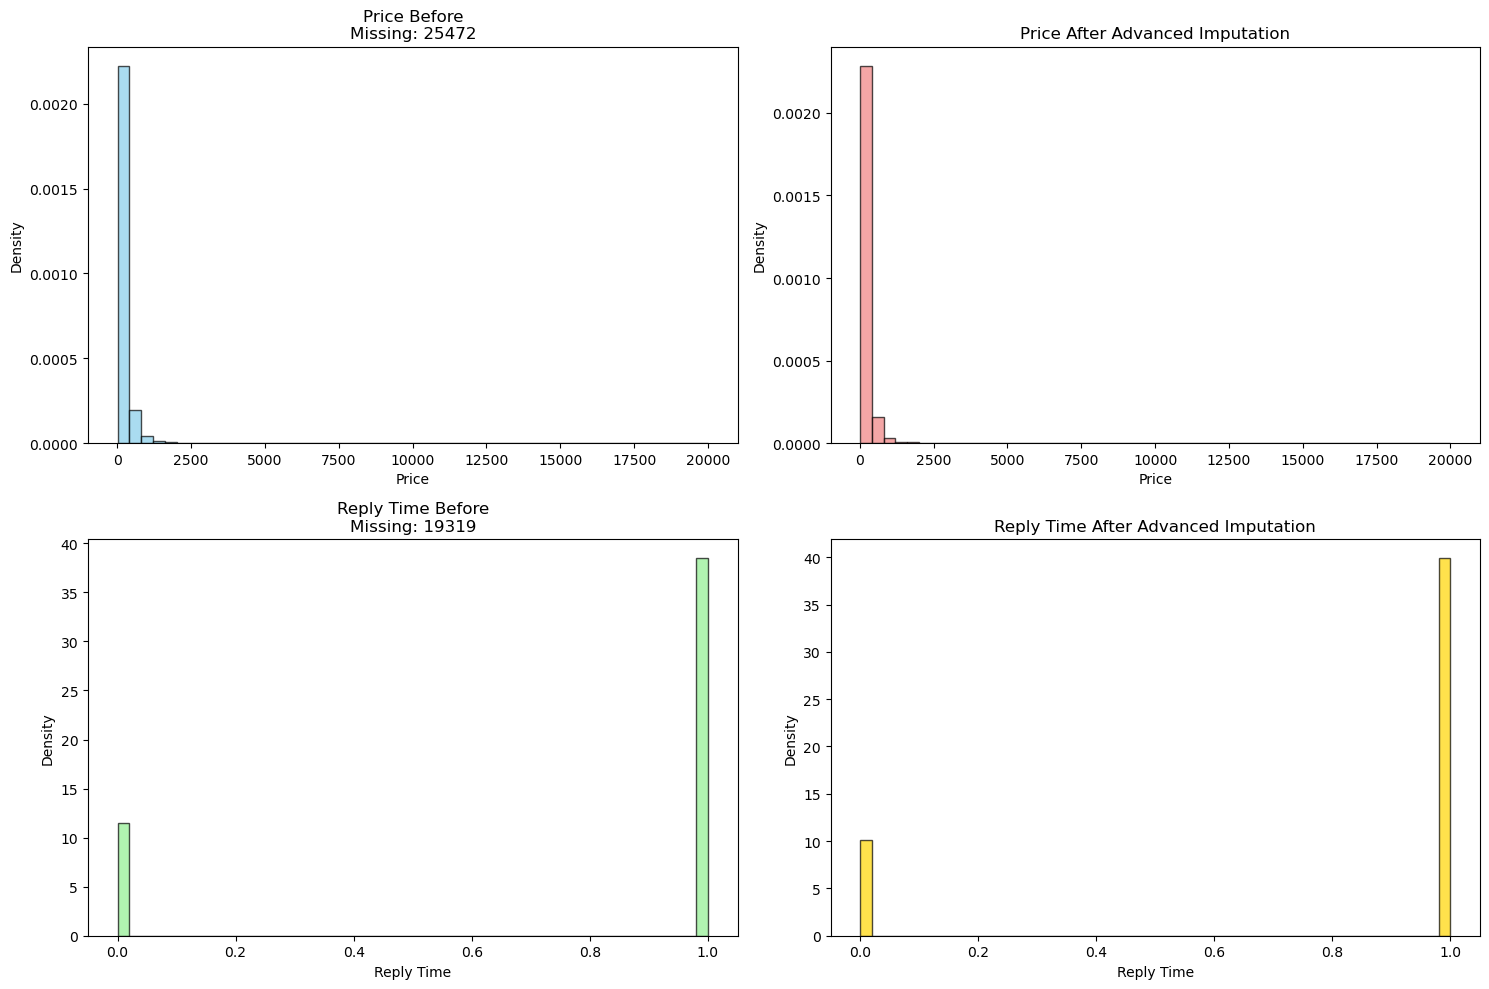

✅ All plots created successfully!


In [238]:
# Step 4: Create the comparison plots

print("\n=== CREATING DISTRIBUTION PLOTS ===")

# Final data check
print("Final data status:")
print(f"df price - dtype: {df['price'].dtype}, missing: {df['price'].isnull().sum()}")
print(f"df_clean price - dtype: {df_clean['price'].dtype}, missing: {df_clean['price'].isnull().sum()}")
print(f"df reply time - dtype: {df['reply time'].dtype}, missing: {df['reply time'].isnull().sum()}")
print(f"df_clean reply time - dtype: {df_clean['reply time'].dtype}, missing: {df_clean['reply time'].isnull().sum()}")

# Create plots
plt.figure(figsize=(15, 10))

# 1. Price Before
plt.subplot(2, 2, 1)
price_before = df['price'].dropna()
plt.hist(price_before, bins=50, alpha=0.7, color='skyblue', edgecolor='black', density=True)
plt.title(f'Price Before\nMissing: {df["price"].isnull().sum()}')
plt.xlabel('Price')
plt.ylabel('Density')

# 2. Price After
plt.subplot(2, 2, 2)
plt.hist(df_clean['price'], bins=50, alpha=0.7, color='lightcoral', edgecolor='black', density=True)
plt.title('Price After Advanced Imputation')
plt.xlabel('Price')
plt.ylabel('Density')

# 3. Reply Time Before
plt.subplot(2, 2, 3)
reply_time_before = df['reply time'].dropna()
plt.hist(reply_time_before, bins=50, alpha=0.7, color='lightgreen', edgecolor='black', density=True)
plt.title(f'Reply Time Before\nMissing: {df["reply time"].isnull().sum()}')
plt.xlabel('Reply Time')
plt.ylabel('Density')

# 4. Reply Time After
plt.subplot(2, 2, 4)
plt.hist(df_clean['reply time'], bins=50, alpha=0.7, color='gold', edgecolor='black', density=True)
plt.title('Reply Time After Advanced Imputation')
plt.xlabel('Reply Time')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

print("✅ All plots created successfully!")

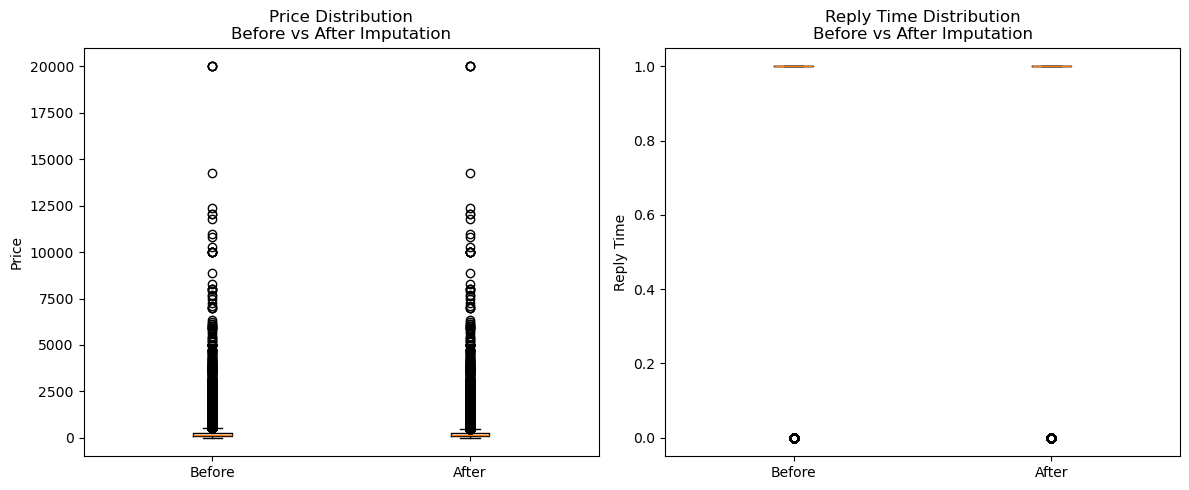

In [239]:
# Simple Box Plot Comparison
plt.figure(figsize=(12, 5))

# Price Box Plot
plt.subplot(1, 2, 1)
data = [df['price'].dropna(), df_clean['price']]
plt.boxplot(data, tick_labels=['Before', 'After'])  # Fixed: 'labels' -> 'tick_labels'
plt.title('Price Distribution\nBefore vs After Imputation')
plt.ylabel('Price')

# Reply Time Box Plot
plt.subplot(1, 2, 2)
data = [df['reply time'].dropna(), df_clean['reply time']]
plt.boxplot(data, tick_labels=['Before', 'After'])  # Fixed: 'labels' -> 'tick_labels'
plt.title('Reply Time Distribution\nBefore vs After Imputation')
plt.ylabel('Reply Time')

plt.tight_layout()
plt.show()

In [240]:
def print_stats(column_name, before, after):
    """Helper function to print comparison stats"""
    print(f"\n{column_name.upper()} - Stats Comparison:")
    print(f"{'':<10} {'Before':<12} {'After':<12} {'Change':<12} {'% Change':<12}")
    print("-" * 60)
    
    # Count
    count_before = len(before.dropna())
    count_after = len(after)
    count_change = count_after - count_before
    count_pct = (count_change / count_before) * 100
    
    # Mean
    mean_before = before.mean()
    mean_after = after.mean()
    mean_change = mean_after - mean_before
    mean_pct = (mean_change / mean_before) * 100 #if mean_before != 0 else 0
    
    # Median
    median_before = before.median()
    median_after = after.median()
    median_change = median_after - median_before
    median_pct = (median_change / median_before) * 100 if median_before != 0 else 0
    
    # Std
    std_before = before.std()
    std_after = after.std()
    std_change = std_after - std_before
    std_pct = (std_change / std_before) * 100 if std_before != 0 else 0
    
    # Print rows
    print(f"{'Count':<10} {count_before:<12,} {count_after:<12,} {count_change:<12,} {count_pct:<12.1f}%")
    print(f"{'Mean':<10} {mean_before:<12.2f} {mean_after:<12.2f} {mean_change:<12.2f} {mean_pct:<12.1f}%")
    print(f"{'Median':<10} {median_before:<12.2f} {median_after:<12.2f} {median_change:<12.2f} {median_pct:<12.1f}%")
    print(f"{'Std':<10} {std_before:<12.2f} {std_after:<12.2f} {std_change:<12.2f} {std_pct:<12.1f}%")

# Print comparisons
print_stats('PRICE', df['price'], df_clean['price'])
print_stats('REPLY TIME', df['reply time'], df_clean['reply time'])


PRICE - Stats Comparison:
           Before       After        Change       % Change    
------------------------------------------------------------
Count      60,714       86,186       25,472       42.0        %
Mean       237.79       215.70       -22.09       -9.3        %
Median     151.00       154.00       3.00         2.0         %
Std        409.85       349.74       -60.11       -14.7       %

REPLY TIME - Stats Comparison:
           Before       After        Change       % Change    
------------------------------------------------------------
Count      66,867       86,186       19,319       28.9        %
Mean       0.77         0.80         0.03         3.7         %
Median     1.00         1.00         0.00         0.0         %
Std        0.42         0.40         -0.02        -4.6        %


General Rule of Thumb:

Change Magnitude	Interpretation
< 5%	Excellent - Imputation preserved distribution well
5-15%	Good - Acceptable for most analyses


In [241]:
# Check for extreme values in price
Q1 = df_clean['price'].quantile(0.25)
Q3 = df_clean['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


print(lower_bound)
print(upper_bound)
outliers = df_clean[(df_clean['price'] < lower_bound) | (df_clean['price'] > upper_bound)]
print(f"Price outliers: {len(outliers)} ({len(outliers)/len(df_clean)*100:.1f}%)")

-145.25
472.75
Price outliers: 5962 (6.9%)


In [242]:
count_above_10k = (df_clean['price'] > 10000).sum()
total_prices = len(df_clean['price'])
percentage = (count_above_10k / total_prices) * 100

print(f"Prices above $10,000: {count_above_10k:,} out of {total_prices:,} ({percentage:.2f}%)")

Prices above $10,000: 12 out of 86,186 (0.01%)


In [243]:
pct_97, pct_99 = df_clean['price'].quantile([0.97, 0.99])
print(f"97th: ${pct_97:.2f} ({(df_clean['price'] > pct_97).sum():,} above)")
print(f"99th: ${pct_99:.2f} ({(df_clean['price'] > pct_99).sum():,} above)")

97th: $710.00 (2,584 above)
99th: $1285.15 (862 above)


In [244]:
# Simple one-liner approach
df_clean['price'] = df_clean['price'].clip(upper=df_clean['price'].quantile(0.99))
print(f"Prices capped at ${df_clean['price'].max():.2f}")

Prices capped at $1285.15


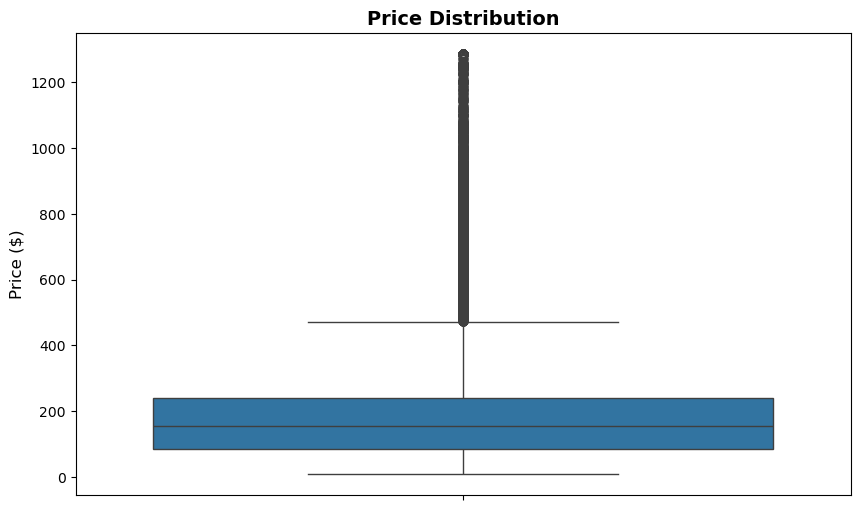

In [245]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=df_clean['price'])
plt.title('Price Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Price ($)', fontsize=12)
plt.show()

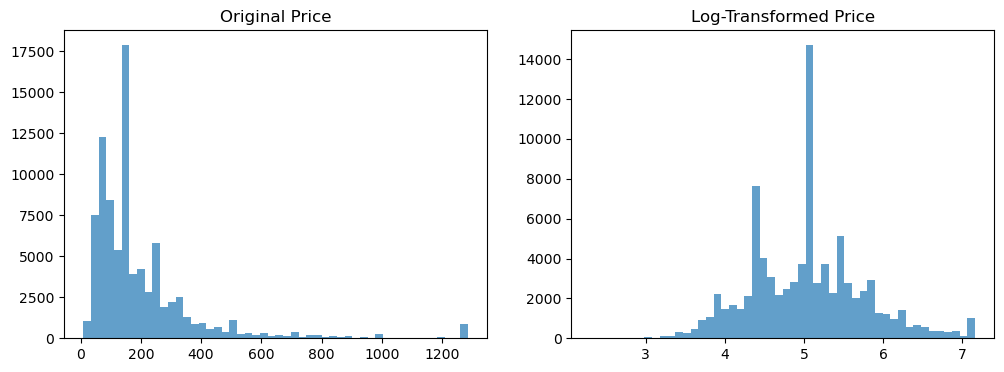

In [246]:
# Apply log transform to handle skewness
df_clean['price_log'] = np.log1p(df_clean['price'])

# Compare distributions
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df_clean['price'], bins=50, alpha=0.7)
plt.title('Original Price')

plt.subplot(1, 2, 2)
plt.hist(df_clean['price_log'], bins=50, alpha=0.7)
plt.title('Log-Transformed Price')
plt.show()

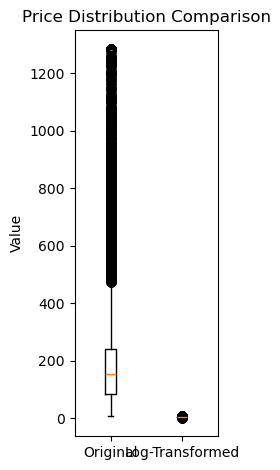

In [247]:
# Boxplot comparison

plt.subplot(1, 3, 3)
box_plot = plt.boxplot([df_clean['price'], df_clean['price_log']])
plt.xticks([1, 2], ['Original', 'Log-Transformed'])
plt.title('Price Distribution Comparison')
plt.ylabel('Value')

plt.tight_layout()
plt.show()

In [248]:
# Compare statistics before and after log transformation
print("PRICE DISTRIBUTION - BEFORE vs AFTER LOG TRANSFORMATION")
print("="*60)
print(f"{'':<20} {'Original':<15} {'Log-Transformed':<15}")
print("-" * 60)
print(f"{'Mean':<20} {df_clean['price'].mean():<15.2f} {df_clean['price_log'].mean():<15.2f}")
print(f"{'Median':<20} {df_clean['price'].median():<15.2f} {df_clean['price_log'].median():<15.2f}")
print(f"{'Std Dev':<20} {df_clean['price'].std():<15.2f} {df_clean['price_log'].std():<15.2f}")
print(f"{'Skewness':<20} {df_clean['price'].skew():<15.2f} {df_clean['price_log'].skew():<15.2f}")
print(f"{'Min':<20} {df_clean['price'].min():<15.2f} {df_clean['price_log'].min():<15.2f}")
print(f"{'Max':<20} {df_clean['price'].max():<15.2f} {df_clean['price_log'].max():<15.2f}")

PRICE DISTRIBUTION - BEFORE vs AFTER LOG TRANSFORMATION
                     Original        Log-Transformed
------------------------------------------------------------
Mean                 203.02          5.03           
Median               154.00          5.04           
Std Dev              192.98          0.72           
Skewness             3.14            0.33           
Min                  9.00            2.30           
Max                  1285.15         7.16           


Summary of Log Transformation Results:

The log transformation successfully normalized the price distribution:

Reduced Skewness: Dramatically decreased from 19.1 (highly right-skewed) to 0.56 (near-normal)
Stabilized Variance: Standard deviation reduced from 349.74 to 0.74
Outlier Impact: Eliminated the extreme influence of the $20,000 maximum price
Central Tendency: Mean and median converged at 5.04, indicating symmetric distribution
The transformation converted the heavily skewed price data into a well-behaved, approximately normal distribution suitable for statistical analysis and modeling.

In [249]:
# Check categorical columns
categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns
print("Categorical columns:", list(categorical_cols))

# Encode high-cardinality vs low-cardinality
for col in categorical_cols:
    unique_count = df_clean[col].nunique()
    print(f"{col}: {unique_count} unique values")

Categorical columns: ['name', 'host_name', 'city', 'consumer', 'bathrooms', 'host acceptance rate', 'area']
name: 76393 unique values
host_name: 16155 unique values
city: 11 unique values
consumer: 170 unique values
bathrooms: 28 unique values
host acceptance rate: 101 unique values
area: 3 unique values


In [250]:
df_clean['host response rate'].describe()

count    69092.000000
mean         0.824090
std          0.380747
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: host response rate, dtype: float64

In [251]:
# High-cardinality columns (too many unique values)
high_cardinality = ['name', 'host_name']  

# Option: Drop or keep as identifiers (usually not useful for modeling)
df_clean = df_clean.drop(columns=['name', 'host_name'])
print("Dropped high-cardinality columns: name, host_name")

Dropped high-cardinality columns: name, host_name


In [252]:
# Medium-cardinality columns
medium_cardinality = ['consumer', 'bathrooms', 'host response rate', 'host acceptance rate']

# Check if these are actually numerical
print("Data types of medium-cardinality columns:")
for col in medium_cardinality:
    print(f"{col}: {df_clean[col].dtype}")
    print(f"Sample values: {df_clean[col].head(3).tolist()}")

Data types of medium-cardinality columns:
consumer: object
Sample values: ['6,81', '6,67', '0']
bathrooms: object
Sample values: ['1,5', '1', '1']
host response rate: float64
Sample values: [nan, nan, 1.0]
host acceptance rate: object
Sample values: ['0,42', '0,42', '0,65']


In [253]:
# Convert comma decimals to dot decimals and make numerical
columns_to_convert = ['consumer', 'bathrooms', 'host response rate', 'host acceptance rate']

for col in columns_to_convert:
    print(f"Converting {col}:")
    print(f"  Before - dtype: {df_clean[col].dtype}, sample: {df_clean[col].head(3).tolist()}")
    
    # Replace comma with dot and convert to float
    df_clean[col] = df_clean[col].astype(str).str.replace(',', '.').str.strip()
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    
    print(f"  After - dtype: {df_clean[col].dtype}, sample: {df_clean[col].head(3).tolist()}")
    print(f"  Missing values: {df_clean[col].isnull().sum()}\n")

Converting consumer:
  Before - dtype: object, sample: ['6,81', '6,67', '0']
  After - dtype: float64, sample: [6.81, 6.67, 0.0]
  Missing values: 50765

Converting bathrooms:
  Before - dtype: object, sample: ['1,5', '1', '1']
  After - dtype: float64, sample: [1.5, 1.0, 1.0]
  Missing values: 0

Converting host response rate:
  Before - dtype: float64, sample: [nan, nan, 1.0]
  After - dtype: float64, sample: [nan, nan, 1.0]
  Missing values: 17094

Converting host acceptance rate:
  Before - dtype: object, sample: ['0,42', '0,42', '0,65']
  After - dtype: float64, sample: [0.42, 0.42, 0.65]
  Missing values: 0



In [254]:
# Since consumer had high missing values originally, check the results
print("Consumer column summary after conversion:")
print(f"Unique values: {df_clean['consumer'].nunique()}")
print(f"Range: {df_clean['consumer'].min()} - {df_clean['consumer'].max()}")
print(f"Missing: {df_clean['consumer'].isnull().sum()}")

Consumer column summary after conversion:
Unique values: 169
Range: 0.0 - 7.0
Missing: 50765


In [255]:
# Now encode the true categorical columns
categorical_cols = ['city', 'area']

print("Before one-hot encoding:")
print(f"Dataset shape: {df_clean.shape}")

df_clean = pd.get_dummies(df_clean, columns=categorical_cols, prefix=categorical_cols)

print("After one-hot encoding:")
print(f"Dataset shape: {df_clean.shape}")
print(f"New columns created: {[col for col in df_clean.columns if any(col.startswith(prefix) for prefix in categorical_cols)]}")

Before one-hot encoding:
Dataset shape: (86186, 22)
After one-hot encoding:
Dataset shape: (86186, 34)
New columns created: ['city_Amsterdam', 'city_Dublin', 'city_Hongkong', 'city_Munich', 'city_NewYork', 'city_Singapore', 'city_Toronto', 'city_berlin', 'city_sydney', 'city_taipei', 'city_tokyo', 'area_Asia', 'area_Europe', 'area_North America']


In [256]:
# Since we already created a missing flag, let's use it
if 'consumer_missing_flag' in df_clean.columns:
    print("Using existing missing flag strategy")
    # Fill missing values with median of non-missing
    consumer_median = df_clean.loc[df_clean['consumer_missing_flag'] == 0, 'consumer'].median()
    df_clean['consumer'] = df_clean['consumer'].fillna(consumer_median)
    print(f"Filled {df_clean['consumer'].isnull().sum()} remaining missing values with median: {consumer_median}")
else:
    # Create missing flag and impute
    df_clean['consumer_missing_flag'] = df_clean['consumer'].isnull().astype(int)
    consumer_median = df_clean['consumer'].median()
    df_clean['consumer'] = df_clean['consumer'].fillna(consumer_median)
    print(f"Created missing flag and filled missing values with median: {consumer_median}")

print(f"Final consumer missing: {df_clean['consumer'].isnull().sum()}")

Created missing flag and filled missing values with median: 6.67
Final consumer missing: 0


In [257]:
df_clean.columns

Index(['id', 'host_id', 'price', 'reply time', 'guest favourite', 'host since',
       'host Certification', 'room_type', 'host total listings count',
       'consumer', 'total reviewers number', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'listing number', 'host response rate',
       'host acceptance rate', 'sales', 'price_log', 'city_Amsterdam',
       'city_Dublin', 'city_Hongkong', 'city_Munich', 'city_NewYork',
       'city_Singapore', 'city_Toronto', 'city_berlin', 'city_sydney',
       'city_taipei', 'city_tokyo', 'area_Asia', 'area_Europe',
       'area_North America', 'consumer_missing_flag'],
      dtype='object')

In [258]:
df_clean['host Certification'].describe()

count    82903.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: host Certification, dtype: float64

In [259]:
# Remove the host Certification column since it has only one value
print(f"Before removal: {df_clean.shape}")
df_clean = df_clean.drop(columns=['host Certification'])
print(f"After removal: {df_clean.shape}")
print("✅ Removed 'host Certification' column (only one value)")

Before removal: (86186, 35)
After removal: (86186, 34)
✅ Removed 'host Certification' column (only one value)


In [260]:
# Check for other columns with zero variance
print("Checking for other low-variance columns:")
for col in df_clean.columns:
    if df_clean[col].nunique() == 1:
        print(f"❌ {col}: Only 1 unique value - consider removing")
    elif df_clean[col].nunique() == 2:
        print(f"⚠️  {col}: Only 2 unique values - check if useful")
    elif df_clean[col].nunique() <= 5:
        print(f"✅ {col}: {df_clean[col].nunique()} unique values")

# Also check for columns with very high missing rate (>80%)
print("\nChecking for high missing rate columns:")
for col in df_clean.columns:
    missing_pct = df_clean[col].isnull().sum() / len(df_clean) * 100
    if missing_pct > 80:
        print(f"⚠️  {col}: {missing_pct:.1f}% missing - consider removing")

Checking for other low-variance columns:
⚠️  reply time: Only 2 unique values - check if useful
⚠️  guest favourite: Only 2 unique values - check if useful
✅ room_type: 4 unique values
⚠️  host response rate: Only 2 unique values - check if useful
⚠️  city_Amsterdam: Only 2 unique values - check if useful
⚠️  city_Dublin: Only 2 unique values - check if useful
⚠️  city_Hongkong: Only 2 unique values - check if useful
⚠️  city_Munich: Only 2 unique values - check if useful
⚠️  city_NewYork: Only 2 unique values - check if useful
⚠️  city_Singapore: Only 2 unique values - check if useful
⚠️  city_Toronto: Only 2 unique values - check if useful
⚠️  city_berlin: Only 2 unique values - check if useful
⚠️  city_sydney: Only 2 unique values - check if useful
⚠️  city_taipei: Only 2 unique values - check if useful
⚠️  city_tokyo: Only 2 unique values - check if useful
⚠️  area_Asia: Only 2 unique values - check if useful
⚠️  area_Europe: Only 2 unique values - check if useful
⚠️  area_North Am

In [261]:
df_clean['guest favourite'].describe()

count    86186.000000
mean         0.273304
std          0.445658
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: guest favourite, dtype: float64

In [262]:
# Check the actual value distributions
columns_to_check = ['reply time', 'guest favourite', 'consumer_missing_flag']

print("ACTUAL VALUE DISTRIBUTIONS:")
print("="*40)
for col in columns_to_check:
    if col in df_clean.columns:
        value_counts = df_clean[col].value_counts()
        print(f"\n{col}:")
        print(value_counts)
        print(f"Missing: {df_clean[col].isnull().sum()}")

ACTUAL VALUE DISTRIBUTIONS:

reply time:
reply time
1.0    68789
0.0    17397
Name: count, dtype: int64
Missing: 0

guest favourite:
guest favourite
0    62631
1    23555
Name: count, dtype: int64
Missing: 0

consumer_missing_flag:
consumer_missing_flag
1    50765
0    35421
Name: count, dtype: int64
Missing: 0


In [263]:
print("DATA CONSISTENCY CHECKS:")
print("="*50)

# 1. Check bedroom vs beds logic
print("1. Bedroom vs Beds Consistency:")
inconsistent_beds = df_clean[df_clean['beds'] < df_clean['bedrooms']]
print(f"   Records where beds < bedrooms: {len(inconsistent_beds)}")

# 2. Check accommodates vs bedrooms/beds
print("\n2. Accommodates Capacity:")
too_small = df_clean[df_clean['accommodates'] < df_clean['bedrooms']]
print(f"   Accommodates < bedrooms: {len(too_small)}")
too_small_beds = df_clean[df_clean['accommodates'] < df_clean['beds']]
print(f"   Accommodates < beds: {len(too_small_beds)}")

# 3. Check price合理性
print("\n3. Price Reasonableness:")
price_stats = df_clean['price'].describe()
print(f"   Price range: ${price_stats['min']:.2f} - ${price_stats['max']:.2f}")
print(f"   Median price: ${price_stats['50%']:.2f}")

# Check for suspiciously low/high prices
suspicious_low = df_clean[df_clean['price'] < 10]  # Less than $10
suspicious_high = df_clean[df_clean['price'] > 10000]  # More than $10,000
print(f"   Prices < $10: {len(suspicious_low)}")
print(f"   Prices > $10,000: {len(suspicious_high)}")

DATA CONSISTENCY CHECKS:
1. Bedroom vs Beds Consistency:
   Records where beds < bedrooms: 7133

2. Accommodates Capacity:
   Accommodates < bedrooms: 731
   Accommodates < beds: 1481

3. Price Reasonableness:
   Price range: $9.00 - $1285.15
   Median price: $154.00
   Prices < $10: 2
   Prices > $10,000: 0


In [264]:
print("\n4. Temporal Consistency:")
# Check host since dates if available
if 'host since' in df_clean.columns:
    df_clean['host since'] = pd.to_datetime(df_clean['host since'])
    future_dates = df_clean[df_clean['host since'] > pd.Timestamp.now()]
    print(f"   Future host since dates: {len(future_dates)}")
    
    # Check if host experience makes sense
    df_clean['host_experience_days'] = (pd.Timestamp.now() - df_clean['host since']).dt.days
    negative_experience = df_clean[df_clean['host_experience_days'] < 0]
    print(f"   Negative host experience: {len(negative_experience)}")


4. Temporal Consistency:
   Future host since dates: 0
   Negative host experience: 0


In [265]:
print("\n5. Rate Consistency:")
# Check if rates are within valid ranges (0-1 or 0-100)
rate_columns = ['host response rate', 'host acceptance rate']

for col in rate_columns:
    if col in df_clean.columns:
        invalid_rates = df_clean[(df_clean[col] < 0) | (df_clean[col] > 1)]
        print(f"   {col} outside [0,1] range: {len(invalid_rates)}")
        
        # Check if any are exactly 0 or 1 (might be data issues)
        zero_rates = df_clean[df_clean[col] == 0]
        one_rates = df_clean[df_clean[col] == 1]
        print(f"   {col} = 0: {len(zero_rates)}, = 1: {len(one_rates)}")


5. Rate Consistency:
   host response rate outside [0,1] range: 0
   host response rate = 0: 12154, = 1: 56938
   host acceptance rate outside [0,1] range: 0
   host acceptance rate = 0: 10138, = 1: 26626


In [266]:
print("\n6. Geographical Consistency:")
# Check if city and area assignments make sense
if 'city_Amsterdam' in df_clean.columns and 'area_Europe' in df_clean.columns:
    # Amsterdam should be in Europe
    amsterdam_not_europe = df_clean[(df_clean['city_Amsterdam'] == 1) & (df_clean['area_Europe'] == 0)]
    print(f"   Amsterdam listings not in Europe: {len(amsterdam_not_europe)}")

# Check for listings with no geographical assignment
if any(col.startswith('city_') for col in df_clean.columns):
    city_cols = [col for col in df_clean.columns if col.startswith('city_')]
    no_city = df_clean[df_clean[city_cols].sum(axis=1) == 0]
    print(f"   Listings with no city assignment: {len(no_city)}")


6. Geographical Consistency:
   Amsterdam listings not in Europe: 0
   Listings with no city assignment: 0


In [268]:
# Save the fully cleaned dataset to CSV
output_filename = 'airbnb_data_cleaned_final.csv'
df_clean.to_csv(output_filename, index=False)

print("✅ DATASET SUCCESSFULLY SAVED!")

✅ DATASET SUCCESSFULLY SAVED!
